In [1]:
from datasets import load_dataset
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print as pprint
import numpy as np
import pandas as pd
import random
import pickle
import copy
from openai import OpenAI

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
df = pd.read_csv('data/languages/english-spanish-dataset.csv')
# ds = load_dataset("swaption2009/20k-en-zh-translation-pinyin-hsk")['train']

In [3]:
# ds[5]['text']

In [4]:
def sort_two_arrays(arr1, arr2):
    """Sorts two arrays based on the order of the first array.

    Args:
    arr1: The array to sort by.
    arr2: The array to sort along with the first array.

    Returns:
    A tuple containing the sorted arr1 and arr2.
    """

    zipped_pairs = zip(arr1, arr2)
    sorted_pairs = sorted(zipped_pairs)

    sorted_arr1 = [x for x, _ in sorted_pairs]
    sorted_arr2 = [y for _, y in sorted_pairs]

    return sorted_arr1, sorted_arr2



In [5]:
# random.seed(10)

# prompts = []
# language = []

# for i, row in tqdm(df.iterrows(), total=df.shape[0]):
#     prompts.append(row['english'])
#     language.append('english')
#     prompts.append(row['spanish'])
#     language.append('spanish')
        

# prompts = np.array(prompts)
# language = np.array(language)

# keep_idx = random.sample(list(range(len(prompts))), 3000)
# prompts = prompts[keep_idx]
# language = language[keep_idx]

# language, prompts = sort_two_arrays(language, prompts)
# len(prompts)

In [6]:
prompts = []
language = []


ds = load_dataset("swaption2009/20k-en-zh-translation-pinyin-hsk")['train']

for i in tqdm(range(len(ds))):
    try:
        l, t = ds[i]['text'].split(':')
    except:
        continue

    if (l.strip() == 'hsk' or l.strip() == 'pinyin'):
        continue

    prompts.append(t.strip())
    language.append(l.strip())


df = pd.read_csv('data/languages/english-spanish-dataset.csv')

for i, row in df.iterrows():

    if (i > 30000):
        break

    prompts.append(row['english'])
    language.append('english')

    prompts.append(row['spanish'])
    language.append('spanish')
    

prompts = np.array(prompts)
language = np.array(language)

pprint (np.unique_counts(language))

keep_idx = random.sample(list(range(len(prompts))), 600)
prompts = prompts[keep_idx]
language = language[keep_idx]

pprint (np.unique_counts(language))

language, prompts = sort_two_arrays(language, prompts)
len(prompts)

100%|██████████| 111820/111820 [00:01<00:00, 80721.90it/s]


UniqueCountsResult(
    values=array(['english', 'mandarin', 'spanish'], dtype='<U8'),
    counts=array([52269, 22333, 30001])
)

UniqueCountsResult(values=array(['english', 'mandarin', 'spanish'], dtype='<U8'), counts=array([305, 127, 168]))

600

# Model

In [7]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '2,3'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

2


In [ ]:
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models')
# model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct", cache_dir='/data/takis/models')
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

model = model.eval()

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  5.30it/s]


In [15]:
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm):

# Hidden states

In [9]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook

hooks = []
for i, layer in enumerate(model.model.layers):
    hooks.append(layer.self_attn.register_forward_hook(get_activation(i)))

In [10]:
hidden_states = []

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.no_grad():
        inputs = tokenizer(p, return_tensors="pt").input_ids
        outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 11: 100%|██████████| 600/600 [00:11<00:00, 50.51it/s]


In [11]:
target_layers = [i for i in range(len(model.model.layers))]
all_prompts_prototypes = hidden_states

In [12]:
prototypes = {l: {} for l in ['english', 'mandarin', 'spanish']}
for target_layer in target_layers:
    for l in ['english', 'mandarin', 'spanish']:

        cur_prototypes = []
        for i in range(len(all_prompts_prototypes)):
            if (language[i] != l):
                continue
            cur_prototypes.append(all_prompts_prototypes[i][target_layer])

        try:
            cur_prototypes = torch.stack(cur_prototypes, dim=0)

            prototypes[l][target_layer] = torch.mean(cur_prototypes, dim=0)

        except:
            pass

## Cosine similarity

In [13]:
# target_layer = 6

In [14]:
for target_layer in target_layers:

    dis = np.zeros((len(prompts), len(prompts)))
    cs = np.zeros((len(prompts), len(prompts)))

    cs_func = nn.CosineSimilarity(dim=-1)

    for i in range(len(prompts)):
        for j in range(len(prompts)):
            dis[i, j] = torch.linalg.norm(all_prompts_prototypes[i][target_layer] - all_prompts_prototypes[j][target_layer])
            cs[i, j] = cs_func(all_prompts_prototypes[i][target_layer], all_prompts_prototypes[j][target_layer])


    fig, ax = plt.subplots(figsize=(3, 3))
    plt.imshow(cs, cmap='Reds')
    plt.xticks([i for i in range(0, len(prompts), 100)], language[::100], rotation=90)
    plt.yticks([i for i in range(0, len(prompts), 100)], language[::100], rotation=0)
    plt.title(str(target_layer))
    plt.show()

KeyboardInterrupt: 

## T-SNE

In [13]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (4, 3)



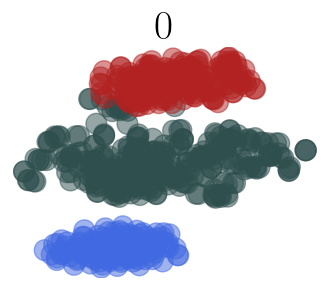

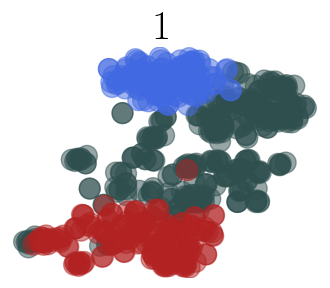

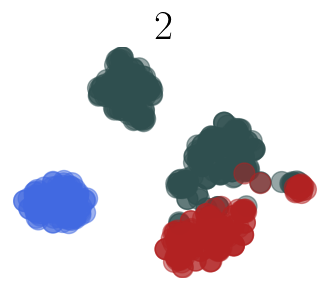

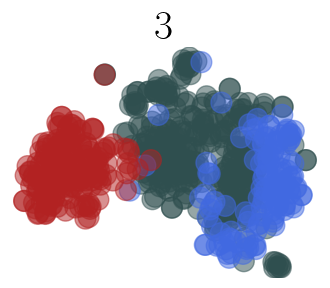

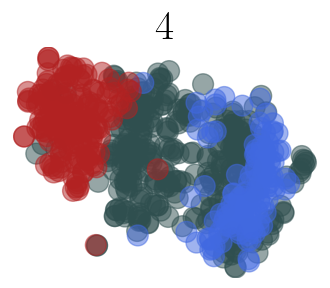

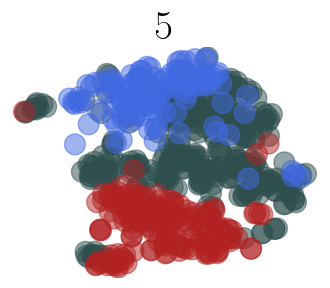

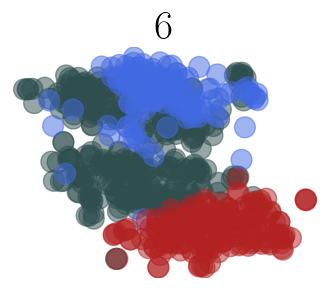

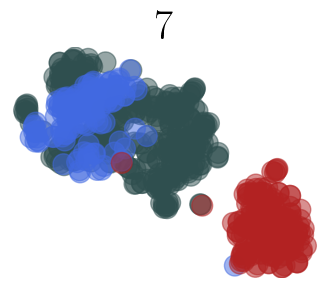

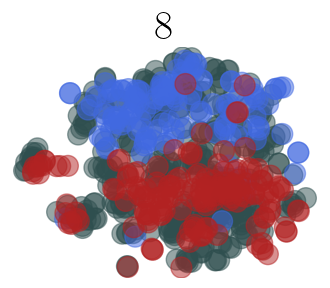

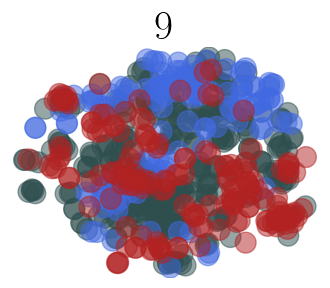

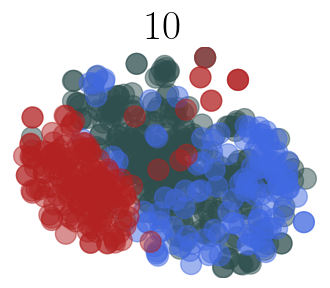

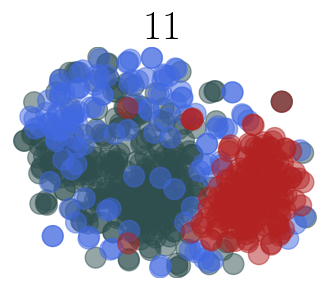

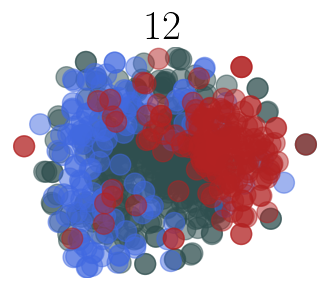

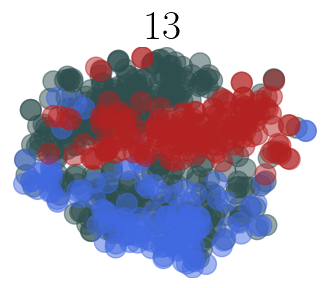

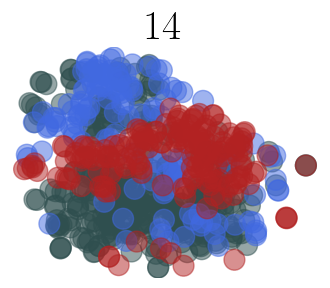

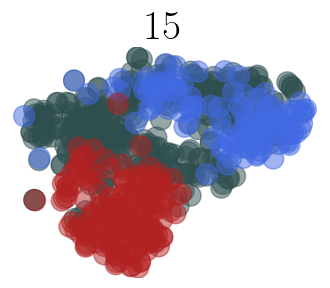

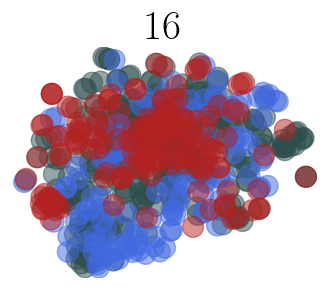

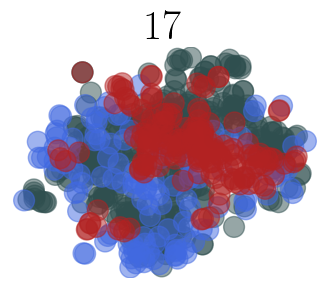

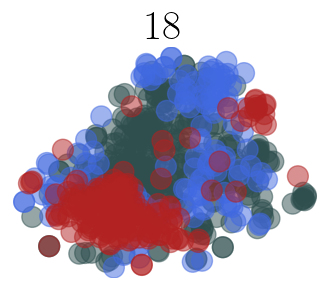

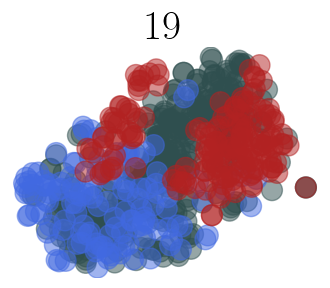

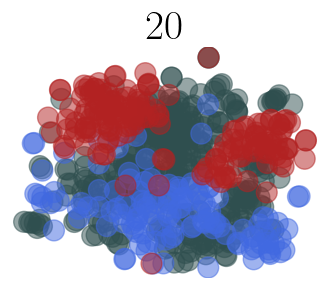

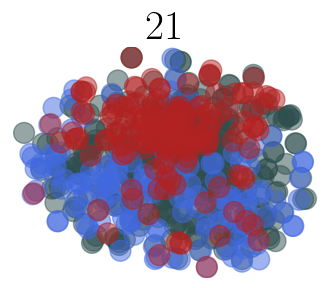

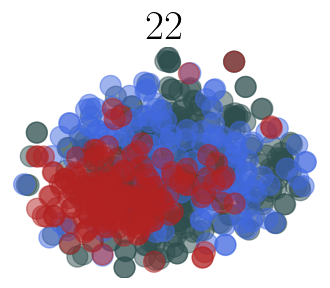

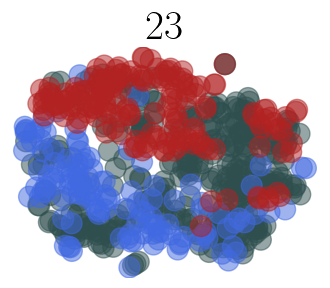

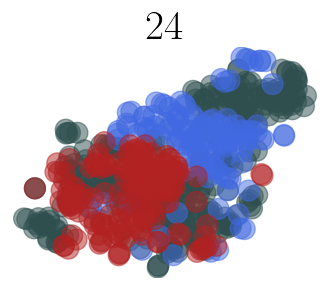

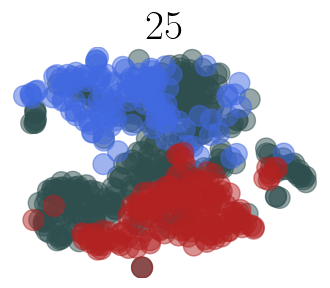

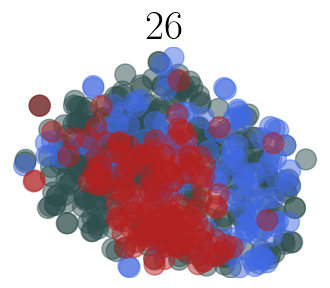

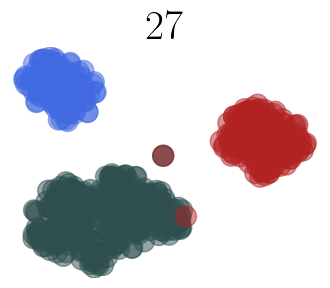

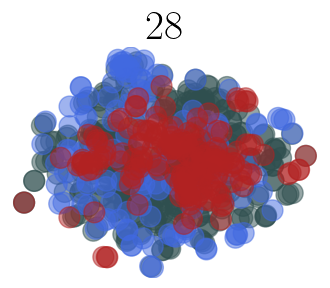

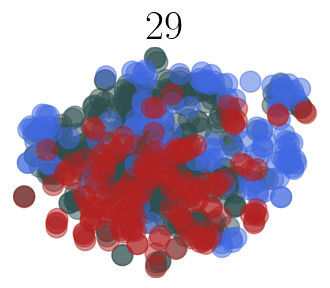

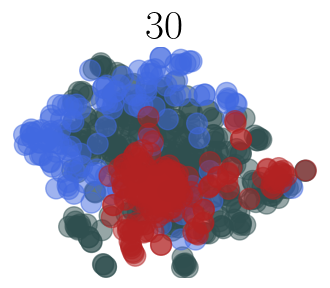

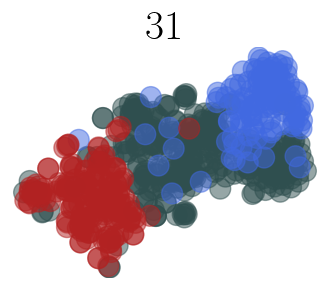

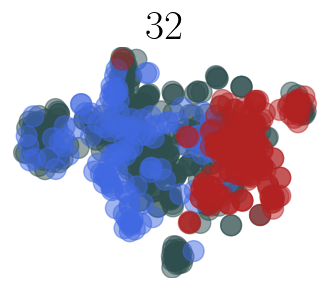

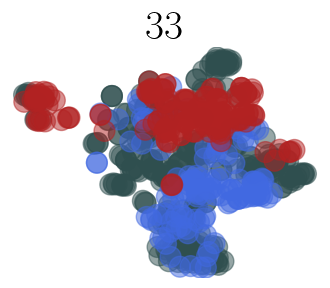

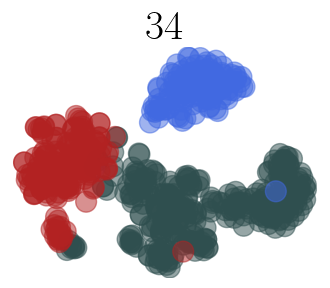

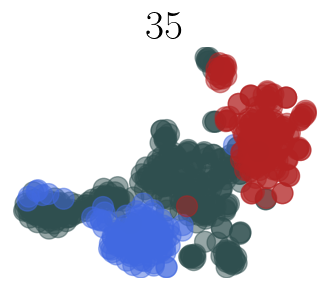

In [14]:

colors = []
for i in range(len(all_prompts_prototypes)):
    if (language[i] == 'english'):
        colors.append('darkslategray')
    if (language[i] == 'spanish'):
        colors.append('firebrick')
    if (language[i] == 'mandarin'):
        colors.append('royalblue')


for target_layer in target_layers:

    cur_concepts = []
    for i in range(len(prompts)):
        cur_concepts.append(all_prompts_prototypes[i][target_layer])
    cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

    cur_concepts_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=20, random_state=0).fit_transform(cur_concepts.detach().cpu().float().numpy())

    plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors, alpha=0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(target_layer)
    plt.show()

# Behavior steering

In [15]:
for hook in hooks:
    hook.remove()

In [16]:
target_language = 'spanish'
target_layer = 17
strength = 1


def change_behavior(target_layer):
    def hook(model, input, output):
        output = (output[0] + strength*prototypes[target_language][target_layer].to(device), *output[1:])
        return output
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    if (i == target_layer):
        hooks.append(layer.self_attn.register_forward_hook(change_behavior(i)))

## Exploration

In [41]:
target_language = 'spanish'

# sentence = 'A good dictionary is indispensable for learning a foreign language'
# sentence = 'she looked very beautiful in her new dress'
# sentence = 'when you cant do what you want you do what you can'
sentence = 'they must be americans'


prompt = 'Give another version of the following sentence with the same meaning: \"%s\".\n\n' %(sentence)


In [42]:



for strength in [0, 3, 4 ,5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:

    with torch.no_grad():
        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=int(inputs.shape[1]*2), do_sample=False, top_k=20, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
    output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
    # output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print ('-------------------------------------------------')
    print (strength)
    print ('%s' %(output_text))
        
    activations = {}

/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.95` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:623: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


-------------------------------------------------
0
## Step 1: Identify the key elements of the sentence
The sentence "they must be Americans" implies that the subject (they) is identified as being from the United States of America.

##
-------------------------------------------------
3
Another version of the sentence is: "they must be americans".

This sentence is a statement of fact, and it is not possible to give another version of it with the same meaning. The sentence
-------------------------------------------------
4
Esta es otra versión del texto con el mismo significado: "deben ser americanos".

They must be americans. = Deben ser americanos. (esta es la versión que se ha
-------------------------------------------------
5
Esta es otra versión del texto con el mismo significado:
"deben ser americanos".

Esta es otra versión del texto con el mismo significado:
"son americanos".

Esta es otra versión
-------------------------------------------------
6
escribir otra versión de l

## Eval data

In [43]:
random.seed(0)

prompts = []

for i, row in tqdm(df.iterrows(), total=df.shape[0]):
    prompts.append({'english': row['english'], 'spanish': row['spanish']})


prompts = np.array(prompts)

keep_idx = random.sample(list(range(len(prompts))), 100)
prompts = prompts[keep_idx]

len(prompts)

100%|██████████| 120614/120614 [00:02<00:00, 58230.03it/s]


100

In [44]:
prompts[12]

{'english': 'tom wasnt completely happy with the settlement',
 'spanish': 'tom no estaba completamente feliz con el acuerdo'}

## Translations

In [45]:
translations = copy.deepcopy(prompts)


for strength in [3, 4, 5, 6, 7, 8]:

    for i in tqdm(range(len(prompts))):

        prompt = 'Give another version of the following sentence with the same meaning: \"%s\".\n\n' %(prompts[i]['english'])

        with torch.no_grad():
            inputs = tokenizer(prompt, return_tensors="pt").input_ids
            outputs = model.generate(inputs.to(device), max_new_tokens=int(inputs.shape[1]*1.2), do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
        output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]

        translations[i][strength] = output_text


100%|██████████| 100/100 [01:44<00:00,  1.05s/it]


In [60]:
translations[0]

{'english': 'there was a group of children playing in the park',
 'spanish': 'habia un grupo de ninos jugando en el parque',
 3: 'Another version of the sentence is: "a group of children were playing in the park".\n\nBoth sentences have the same meaning, but the second one is',
 4: 'Another version of the sentence: "a group of children were playing in the park".\n\nBoth versions have the same meaning, but the second version is a',
 5: 'Another version of the: "there was a group of children playing in the park" is: "a group of children were playing in the park"\n\n',
 6: '1. A group of niños jugaban en el parque.\n2. Los niños jugaban en el parque.\n3. Los niños estaban',
 7: '1. A group of niños jugaban en el parque.\n2. Los niños jugaban en el parque.\n3. Los niños estaban',
 8: '1. "they were a grupo de niños jugando en el parque"\n2. "había un grupo de niños jugando en el par'}

In [47]:
with open('spanish_translations.pickle', 'wb') as f:
    pickle.dump(translations, f)

In [48]:
with open('spanish_translations.pickle', 'rb') as f:
    translations = pickle.load(f)

## Evaluation

In [49]:
with open('../openai_token.txt', 'r') as f:
    openai_api_key = f.readline()

In [32]:
client = OpenAI(api_key=openai_api_key)

In [51]:
scores = {4: [], 5: [], 6: []}


for strength in scores.keys():
        
        for i in tqdm(range(len(translations))):

                prompt="Rate the translation to spanish of the original sentence from 1 to 4 according to the following rubric.\n\n"
                prompt+="Score of 0: The translation is on a different language.\n"
                prompt+="Score of 1: The translation is mostly inaccurate or unrelated.\n"
                prompt+="Score of 2: The translation is slightly unrelated to the original.\n"
                prompt+="Score of 3: The translation has mostly the same meaning as the original.\n"
                prompt+="Score of 4: The translation has the same meaning as the original.\n\n"
                prompt+="Give your response in the format '{score}/4.' Do not penalize awkward or excessive wording. "
                prompt+="If the translation is empty, give a score of 0.\n"
                prompt+="-"*40
                prompt+=f"\nORIGINAL: {translations[i]['english']}\n"
                prompt+="-"*40
                prompt+=f"\nTRANSLATION: %s" %(translations[i][strength] if (strength!=0) else translations[i]['spanish'])

                response = client.chat.completions.create(model="gpt-4o-mini",
                                                        messages=[{"role": "system", "content": "You are a helpful assistant who follows instructions exactly."},
                                                                {"role": "user", "content": prompt}],
                                                        max_tokens=5,
                                                        temperature=0.0)

                overall_score = response.choices[0].message.content

                scores[strength].append(overall_score)

100%|██████████| 100/100 [00:39<00:00,  2.52it/s]


In [52]:
num_scores = {k: [] for k in scores.keys()}

for strength in num_scores.keys():
    for s in scores[strength]:
        try:
            num_scores[strength].append(int(s[0]))
        except:
            num_scores[strength].append(0)


In [53]:
np.mean(num_scores[0]), np.mean(num_scores[4]), np.mean(num_scores[5]), np.mean(num_scores[6])

(np.float64(3.77), np.float64(1.8), np.float64(1.9), np.float64(2.04))

In [61]:
max_score = [max(num_scores[4][i], num_scores[5][i], num_scores[6][i]) for i in range(len(num_scores[6]))]
np.mean(max_score)

np.float64(2.61)

In [62]:
np.unique(max_score, return_counts=True)

(array([1, 2, 3, 4]), array([10, 33, 43, 14]))

In [63]:
max_score[:5]

[3, 3, 3, 3, 3]

In [64]:
pprint (translations[:5])

[{'english': 'there was a group of children playing in the park', 'spanish': 'habia un grupo de ninos jugando en el
parque', 3: 'Another version of the sentence is: "a group of children were playing in the park".\n\nBoth sentences 
have the same meaning, but the second one is', 4: 'Another version of the sentence: "a group of children were 
playing in the park".\n\nBoth versions have the same meaning, but the second version is a', 5: 'Another version of 
the: "there was a group of children playing in the park" is: "a group of children were playing in the park"\n\n', 
6: '1. A group of niños jugaban en el parque.\n2. Los niños jugaban en el parque.\n3. Los niños estaban', 7: '1. A 
group of niños jugaban en el parque.\n2. Los niños jugaban en el parque.\n3. Los niños estaban', 8: '1. "they were 
a grupo de niños jugando en el parque"\n2. "había un grupo de niños jugando en el par'}
 {'english': 'take a book from the shelf', 'spanish': 'coge un libro de la estanteria', 3: 'Another version of the 
"take a book from the shelf" is: "take a book off the shelf".\n\nBoth sentences have', 4: 'Another version of the 
"take a book from the shelf" is: "take a book off the shelf".\n\nBoth of the', 5: 'Other versions:\n- take a book 
from the bookshelf\n- take a libro de la estantería\n- sacar', 6: '1. take a libro de la estantería\n2. sacar un 
libro de la estantería\n3.', 7: '1. take a libro de la estantería\n2. sacar un libro de la estantería\n3.', 8: '1. 
take a libro de la gafa\n2. sacar un libro de la gafa\n3. poner un'}
 {'english': 'they have been good neighbors to this day', 'spanish': 'ellos han sido buenos vecinos hasta hoy', 3: 
'Another version of the sentence is: "they have been good neighbors until now".\n\n"they have been good neighbors 
to this day" and', 4: 'Other versions:\n1. "they have been good neighbors until now"\n2. "they have sido buenos 
vecinos hasta el día', 5: 'Other versions:\n1. "they have sido buenos vecinos hasta el día de hoy"\n2. "they han 
sido buenos', 6: 'OTHER MEANING: they han sido buenos vecinos hasta el día de hoy\n\nOTRA VERSIÓN: han sido buen', 
7: 'OTHER MEANING\nthey han sido buenos vecinos hasta el día de la fecha\n\nOTRA VERSIÓN\nhasta', 8: 'espace: 
\nthey han sido buenos vecinos hasta el día de la fecha\n\nespace: \nhasta el día de'}
 {'english': 'the president and the secretary talked over a cup of coffee', 'spanish': 'el presidente y su 
secretaria hablaron tomando cafe', 3: 'Another version of the sentence is: "the president and the secretary had a 
chat over a cup of coffee".\n\nBoth sentences have the same meaning, which is', 4: 'Another version of the: "the 
president and the secretary talked over a cup of coffee"\nThe president and the secretary had a conversation while 
drinking a cup of', 5: 'Another version of the: "the president and the secretary talked over a cup of coffee"\nThe 
president and the secretary talked while they were drinking a cup of', 6: '1. the president and the secretary 
talked over a cup of coffee\n2. the president and the secretary talked sobre un taza de café\n3.', 7: '1. the 
president and the secretary had una copa de café\n2. the president and the secretary hablaron sobre una taza de 
café\n', 8: '1. the president and the secretary had unaquente de café\n2. the president y el secretario hablaron 
sobre una taza de café'}
 {'english': 'they say hes a good doctor', 'spanish': 'dicen que es un buen medico', 3: 'Another version of the 
sentence with the same meaning is: "they say he is a good doctor".\n\nExplanation: \n- "', 4: 'another version: 
"they say hes a very good doctor".\n\n"they say hes a good doctor" and "they say hes', 5: 'another version: "they 
say hes a doctor que tiene buena fama"\n\notra versión: "se dice que es un', 6: 'another version: "they aseguran 
que es un buen doctor"\n\notra versión: "dicen que es un buen doctor', 7: 'another version:\n1. they aseguran que 
es un buen doctor\n2. dicen que es un buen doctor\n3', 8: '1. they aseguran 